Import Libraries




In [14]:
# استيراد كل المكتبات اللي رح نحتاجها
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# مكتبات النماذج
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# مكتبات التقييم
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,confusion_matrix, classification_report,precision_recall_curve, brier_score_loss,ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve



In [34]:
# Load Dataset
df = pd.read_csv('../OnlineNewsPopularity/OnlineNewsPopularity.csv')

# Clean column names (some columns may contain extra spaces)
df.columns = df.columns.str.strip()

# Display dataset information
print("Dataset Shape:", df.shape)

print("\nFirst 3 Rows:")
df.head(3)

Dataset Shape: (39644, 61)

First 3 Rows:


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.5,-0.1875,0.0,0.1875,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.0,0.0000,0.5,0.0000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.0,0.0000,0.5,0.0000,1500


Target

Median Shares: 1400.0

Class Distribution:
popular
1    21154
0    18490
Name: count, dtype: int64

Popular Articles Ratio: 53.4%


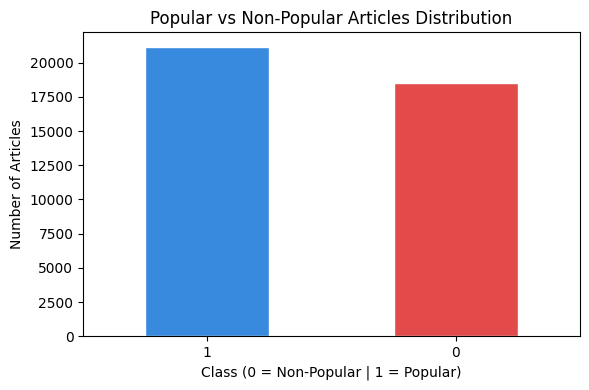

In [35]:
# Create Binary Target Variable

median_shares = df['shares'].median()
print(f"Median Shares: {median_shares}")

df['popular'] = (df['shares'] >= median_shares).astype(int)

# Class Distribution
print("\nClass Distribution:")
print(df['popular'].value_counts())

print(f"\nPopular Articles Ratio: {df['popular'].mean() * 100:.1f}%")

# Plot Class Distribution
plt.figure(figsize=(6, 4))

df['popular'].value_counts().plot(
    kind='bar',
    color=['#378ADD', '#E24B4A'],
    edgecolor='white'
)

plt.title('Popular vs Non-Popular Articles Distribution')
plt.xlabel('Class (0 = Non-Popular | 1 = Popular)')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [36]:
# Remove non-feature columns (URL, original target, and new target)
cols_to_drop = ['url', 'shares', 'popular']

X = df.drop(columns=cols_to_drop)
y = df['popular']

print(f"Number of Features: {X.shape[1]}")
print(f"Number of Rows: {X.shape[0]}")

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,          # Ensures reproducible results
    stratify=y           )    # Preserves class distribution
print(f"\nTraining Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")

# Feature Scaling
# Important for Logistic Regression, KNN, and SVM
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)



Number of Features: 59
Number of Rows: 39644

Training Set Shape: (31715, 59)
Testing Set Shape: (7929, 59)


Train each model

In [37]:
# Define all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)}

# Train each model and store results
results = {}

for name, model in models.items():
    print(f"Training {name}...")

 # Models that require scaled data
if name in ['Logistic Regression', 'KNN', 'SVM (Linear)', 'SVM (RBF)']:
     model.fit(X_train_scaled, y_train)
     y_pred = model.predict(X_test_scaled)
     y_prob = model.predict_proba(X_test_scaled)[:, 1]
else:
     model.fit(X_train, y_train)
     y_pred = model.predict(X_test)
     y_prob = model.predict_proba(X_test)[:, 1]

 # Calculate evaluation metrics
results[name] = {
     'model': model,
     'y_pred': y_pred,
     'y_prob': y_prob,
     'accuracy': accuracy_score(y_test, y_pred),
     'precision': precision_score(y_test, y_pred),
     'recall': recall_score(y_test, y_pred),
     'f1': f1_score(y_test, y_pred),
     'auc': roc_auc_score(y_test, y_prob),
     'brier': brier_score_loss(y_test, y_prob) }

print(f"{name} - Accuracy: {results[name]['accuracy']:.3f} | F1: {results[name]['f1']:.3f}")

Training Logistic Regression...
Training KNN...
Training SVM (Linear)...
Training SVM (RBF)...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
XGBoost - Accuracy: 0.659 | F1: 0.685


Comparison Table

Model Comparison:
        Accuracy Precision Recall F1-Score AUC-ROC Brier Score
XGBoost    0.659     0.675  0.695    0.685   0.718       0.217


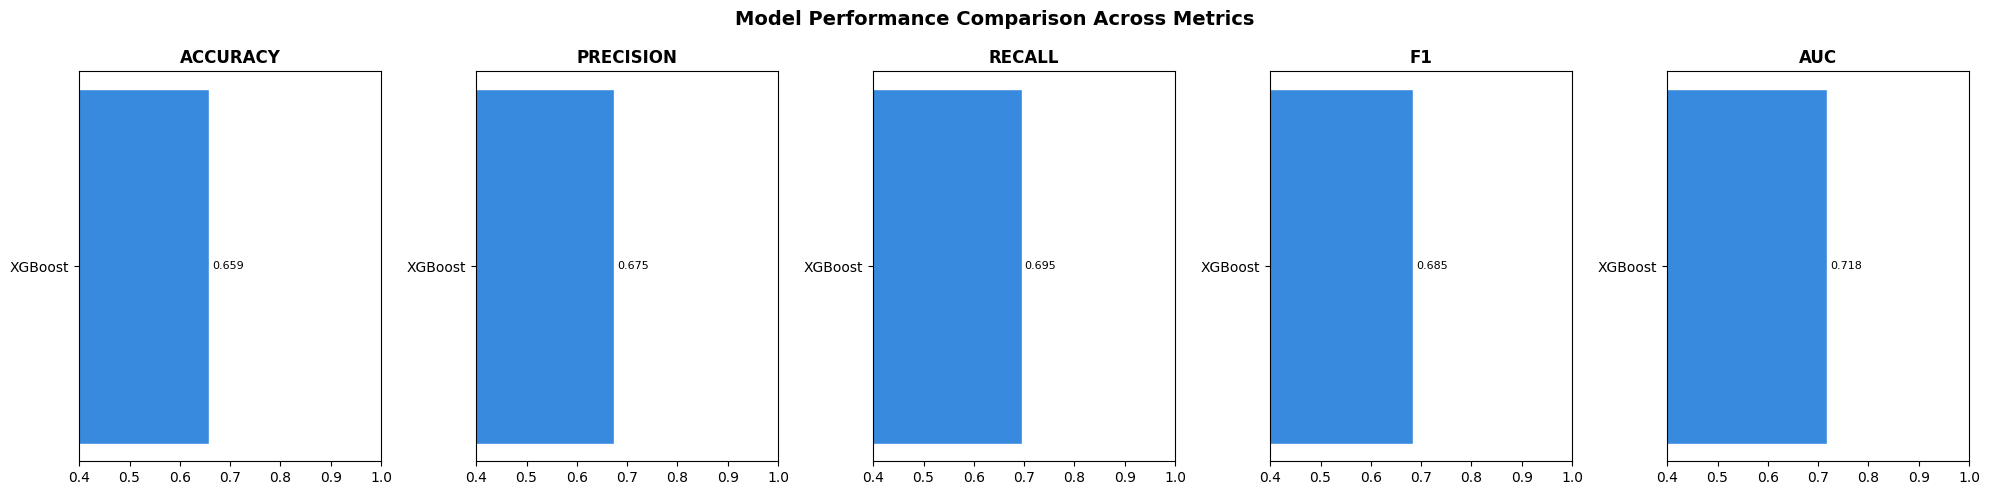

In [38]:
# Create Comparison Table
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': f"{v['accuracy']:.3f}",
        'Precision': f"{v['precision']:.3f}",
        'Recall': f"{v['recall']:.3f}",
        'F1-Score': f"{v['f1']:.3f}",
        'AUC-ROC': f"{v['auc']:.3f}",
        'Brier Score': f"{v['brier']:.3f}"}
    for name, v in results.items()  }).T

print("Model Comparison:")
print(comparison_df.to_string())

# Visual Comparison of Models
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
model_names = list(results.keys())

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, metric in enumerate(metrics):
    values = [results[m][metric] for m in model_names]
    bars = axes[i].barh(
        model_names,
        values,
        color='#378ADD',
        edgecolor='white' )

    axes[i].set_title(metric.upper(), fontweight='bold')
    axes[i].set_xlim(0.4, 1.0)

    for bar, val in zip(bars, values):
        axes[i].text(
            val + 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center',
            fontsize=8 )
plt.suptitle(
    'Model Performance Comparison Across Metrics',
    fontsize=14,
    fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()


ROC Curves

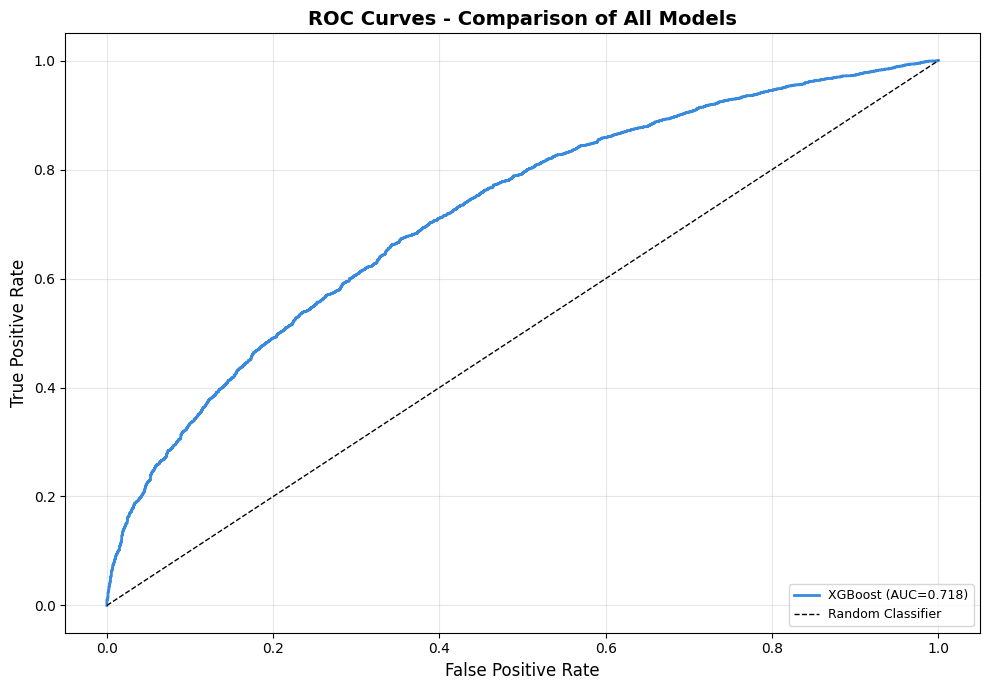

In [39]:
plt.figure(figsize=(10, 7))
colors = ['#378ADD','#639922','#D85A30','#D4537E','#534AB7','#BA7517','#1D9E75']

for (name, v), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={v['auc']:.3f})",
        color=color,
        linewidth=2  )

plt.plot([0, 1], [0, 1],
         'k--',
         label='Random Classifier',
         linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)

plt.title(
    'ROC Curves - Comparison of All Models',
    fontsize=14,
    fontweight='bold')

plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

Best Model Selection and Evaluation

Best Model: XGBoost
F1-Score: 0.685
AUC: 0.718


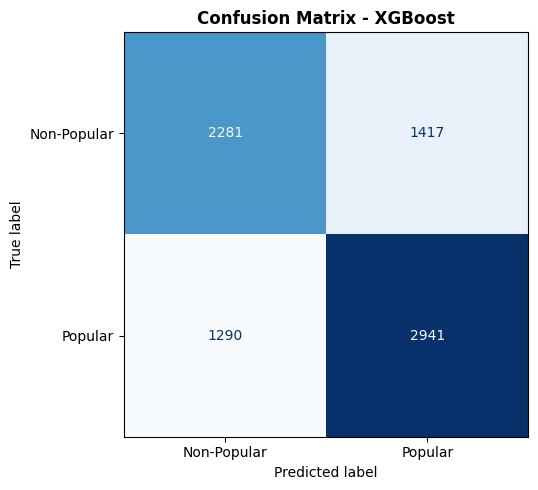


Classification Report:
              precision    recall  f1-score   support

 Non-Popular       0.64      0.62      0.63      3698
     Popular       0.67      0.70      0.68      4231

    accuracy                           0.66      7929
   macro avg       0.66      0.66      0.66      7929
weighted avg       0.66      0.66      0.66      7929



In [40]:
# Find the best model based on F1-Score
best_model_name = max(results, key=lambda x: results[x]['f1'])
best = results[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"F1-Score: {best['f1']:.3f}")
print(f"AUC: {best['auc']:.3f}")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best['y_pred'])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Popular', 'Popular'])

disp.plot(
    ax=ax,
    colorbar=False,
    cmap='Blues')

ax.set_title(
    f'Confusion Matrix - {best_model_name}',
    fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Detailed Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best['y_pred'],
        target_names=['Non-Popular', 'Popular']
    ) )

 Learning Curve Analysis

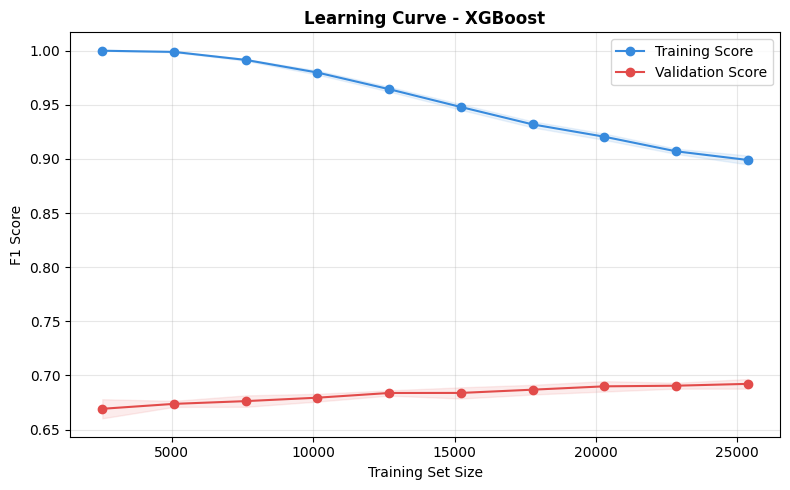

In [41]:
def plot_learning_curve(model, X, y, name, scaled=False):
    if scaled:
      X = scaler.transform(X)
    
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
         scoring='f1')
    
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_std = val_scores.std(axis=1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', color='#378ADD', label='Training Score')
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='#378ADD')
    plt.plot(train_sizes, val_mean, 'o-', color='#E24B4A', label='Validation Score')
    plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1, color='#E24B4A')
    plt.title(f'Learning Curve - {name}', fontweight='bold')
    plt.xlabel('Training Set Size')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'learning_curve_{name.replace(" ", "_")}.png', dpi=150)
    plt.show()

# Plot learning curve for the best model
needs_scaling = best_model_name in ['Logistic Regression', 'KNN', 'SVM (Linear)', 'SVM (RBF)']
plot_learning_curve(best['model'], X_train, y_train, best_model_name, scaled=needs_scaling)